# Notebook 02 — ColPali + CLIP Indexing (Kaggle T4) — FAST VERSION

Indexes only the corpus images (~3,652) using direct colpali-engine (no byaldi).

**Setup:** Add Kaggle Input: `raddar/chest-xrays-indiana-university`

In [1]:
!pip install -q --upgrade peft transformers
!pip install -q colpali-engine accelerate open-clip-torch faiss-cpu
!pip install -q --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 13.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 83.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 68.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 74.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.7 MB/s eta 0:00:0000:0100:01


In [2]:
import os, sys, subprocess, importlib.util, glob, time

WORKING_DIR = '/kaggle/working'
COLPALI_INDEX_DIR = os.path.join(WORKING_DIR, 'colpali_index')
CLIP_INDEX_DIR = os.path.join(WORKING_DIR, 'clip_index')

os.makedirs(COLPALI_INDEX_DIR, exist_ok=True)
os.makedirs(CLIP_INDEX_DIR, exist_ok=True)

# Auto-detect images dir
png_matches = glob.glob('/kaggle/input/**/*.png', recursive=True)
if not png_matches:
    raise RuntimeError('No PNGs in /kaggle/input/ - add Kaggle Input dataset')
IMAGES_DIR = os.path.dirname(png_matches[0])
print(f'✓ Found {len(png_matches)} images at {IMAGES_DIR}')

# Clone repo
REPO_PATH = os.path.join(WORKING_DIR, 'cxr-rag-system')
if not os.path.exists(REPO_PATH):
    subprocess.run(['git', 'clone', '-q', 'https://github.com/mohamedtaha77/cxr-rag-system.git', REPO_PATH], check=True)
else:
    subprocess.run(['git', '-C', REPO_PATH, 'pull', '-q'], check=True)

print('✓ Setup complete')

✓ Found 7470 images at /kaggle/input/datasets/raddar/chest-xrays-indiana-university/images/images_normalized
✓ Setup complete


In [3]:
# Load modules (force fresh load)
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

colpali_mod = load_module('colpali_retriever', os.path.join(REPO_PATH, 'src', 'retrieval', 'colpali_retriever.py'))
clip_mod = load_module('clip_retriever', os.path.join(REPO_PATH, 'src', 'retrieval', 'clip_retriever.py'))

ColPaliRetriever = colpali_mod.ColPaliRetriever
CLIPRetriever = clip_mod.CLIPRetriever

print('✓ Modules loaded')

✓ Modules loaded


## ColPali Indexing (Fast — Direct colpali-engine)

In [4]:
import torch, gc, pandas as pd

torch.cuda.empty_cache()
gc.collect()

if os.path.exists(os.path.join(COLPALI_INDEX_DIR, 'colpali_embeddings.pt')):
    print('Loading ColPali index from disk...')
    retriever = ColPaliRetriever.from_index(COLPALI_INDEX_DIR)
    print('✓ Loaded')
else:
    # Index only corpus images (much faster than indexing all 7470)
    corpus_df = pd.read_csv('/kaggle/input/notebooks/mohammedtaha778/01-data-qa-dataset-200-studies/reports_corpus.csv')
    corpus_images = corpus_df['image_path'].tolist()
    existing_images = [p for p in corpus_images if os.path.exists(p)]
    print(f'Indexing {len(existing_images)} corpus images...')
    
    start = time.time()
    retriever = ColPaliRetriever()
    retriever.build_index(image_paths=existing_images, index_save_dir=COLPALI_INDEX_DIR)
    elapsed = time.time() - start
    print(f'✓ Built in {elapsed/60:.1f} min')

Indexing 3652 corpus images...


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


adapter_config.json:   0%|          | 0.00/751 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/34.6M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

Indexing 3652 images with batch size 1...


100%|██████████| 3652/3652 [2:39:17<00:00,  2.62s/it]  


Index built: torch.Size([3652, 1031, 128])
Index saved to /kaggle/working/colpali_index
✓ Built in 160.2 min


[transformers] It is a prefill stage but The `token_type_ids` is not provided. We recommend passing `token_type_ids` to the model to prevent bad attention masking.


ColPali top-3 results


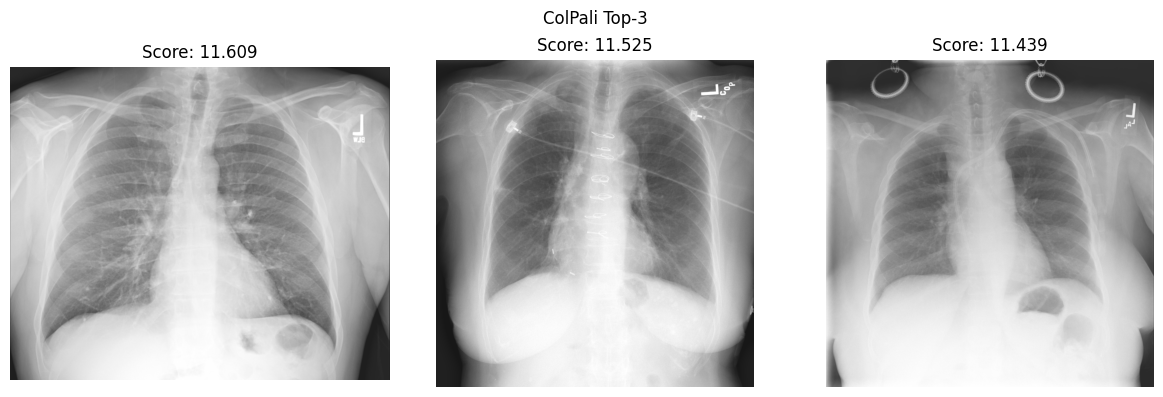

In [5]:
# Test ColPali
results = retriever.search('pleural effusion bilateral', k=3)
print(f'ColPali top-{len(results)} results')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(results), figsize=(12, 4))
if len(results) == 1: axes = [axes]
for ax, r in zip(axes, results):
    if r['image']: ax.imshow(r['image'], cmap='gray')
    ax.set_title(f"Score: {r['score']:.3f}")
    ax.axis('off')
plt.suptitle('ColPali Top-3')
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'colpali_retrieval.png'), dpi=100)
plt.show()

In [6]:
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

VRAM: 5.94 GB


In [7]:
# Free memory before CLIP
del retriever
gc.collect()
torch.cuda.empty_cache()
print(f'VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

VRAM: 0.01 GB


## CLIP Indexing

In [8]:
# Index only corpus images for CLIP too (consistency)
if not 'existing_images' in dir():
    corpus_df = pd.read_csv('/kaggle/working/reports_corpus.csv')
    existing_images = [p for p in corpus_df['image_path'].tolist() if os.path.exists(p)]

print(f'Building CLIP index on {len(existing_images)} images...')

if os.path.exists(os.path.join(CLIP_INDEX_DIR, 'index.faiss')):
    print('Loading CLIP index...')
    clip_retriever = CLIPRetriever()
    clip_retriever.load_index(CLIP_INDEX_DIR)
    print('✓ Loaded')
else:
    print('Building CLIP index (~10-15 min)...')
    clip_retriever = CLIPRetriever()
    clip_retriever.build_index(existing_images, batch_size=128)
    clip_retriever.save_index(CLIP_INDEX_DIR)
    print('✓ Built')

Building CLIP index on 3652 images...
Building CLIP index (~10-15 min)...


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✓ Built


CLIP top-3 results


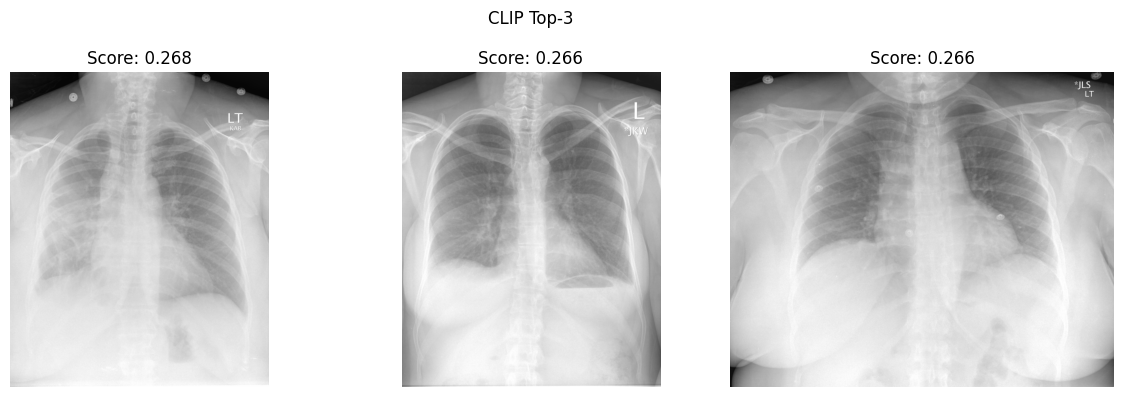


✓ Both indexes ready in /kaggle/working


In [9]:
# Test CLIP
results_clip = clip_retriever.search_by_text('pleural effusion bilateral', k=3)
print(f'CLIP top-{len(results_clip)} results')

fig, axes = plt.subplots(1, len(results_clip), figsize=(12, 4))
if len(results_clip) == 1: axes = [axes]
for ax, r in zip(axes, results_clip):
    if r['image']: ax.imshow(r['image'], cmap='gray')
    ax.set_title(f"Score: {r['score']:.3f}")
    ax.axis('off')
plt.suptitle('CLIP Top-3')
plt.tight_layout()
plt.savefig(os.path.join(WORKING_DIR, 'clip_retrieval.png'), dpi=100)
plt.show()

print(f'\n✓ Both indexes ready in {WORKING_DIR}')